In [1]:
# Cell 1: Import Library
import pandas as pd
import numpy as np
import ast
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_curve, auc, confusion_matrix, roc_auc_score
)
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm

# Mengatur style plot agar terlihat lebih baik
plt.style.use('seaborn-v0_8')

In [2]:
# Cell 2: Memuat Dataset
# Pastikan file 'spotify_dataset.csv' berada di direktori yang sama dengan notebook ini
try:
    spotify_dataset = pd.read_csv('spotify_dataset.csv')
    print("Dataset 'spotify_dataset.csv' berhasil dimuat.")
except FileNotFoundError:
    print("Error: File 'spotify_dataset.csv' tidak ditemukan. Pastikan file berada di direktori yang benar.")
    # Buat DataFrame dummy agar kode selanjutnya tidak error jika file tidak ditemukan
    spotify_dataset = pd.DataFrame()

Dataset 'spotify_dataset.csv' berhasil dimuat.


In [3]:
# Cell 3: Mengambil 200 Baris Teratas
if not spotify_dataset.empty:
    spotify_dataset = spotify_dataset.copy() # Menggunakan .copy() untuk menghindari SettingWithCopyWarning
    print(f"Shape awal dataset: {spotify_dataset.shape}")
else:
    spotify_dataset = pd.DataFrame()
    print("Dataset kosong, tidak dapat mengambil 200 baris teratas.")

Shape awal dataset: (1556, 23)


In [4]:
# Cell 4: Data Exploration - Pemeriksaan Awal
if not spotify_dataset.empty:
    print("--- Data Exploration ---")

    # 1.1 Pemeriksaan Missing Values
    missing_values = spotify_dataset.isnull().sum()
    print("\nMissing values di setiap kolom:")
    print(missing_values[missing_values > 0])
    if missing_values.sum() == 0:
        print("Observasi: Tidak ada missing values pada 200 baris teratas dataset ini.")
    else:
        print("Observasi: Terdapat missing values pada dataset ini.")

    # 1.2 Pemeriksaan Tipe Data
    print("\nTipe data kolom-kolom:")
    print(spotify_dataset.dtypes)

    # 1.3 Ringkasan Statistik untuk Kolom Numerik
    print("\nRingkasan Statistik untuk Kolom Numerik:")
    print(spotify_dataset.select_dtypes(include=np.number).describe())

    print("\nObservasi awal dari ringkasan statistik:")
    print("- Kolom numerik seperti 'Index', 'Highest Charting Position', dan 'Number of Times Charted' memiliki rentang nilai yang wajar.")
    print("- Kolom lain yang seharusnya numerik (seperti 'Streams', 'Artist Followers', 'Popularity') mungkin masih dalam format objek karena adanya koma atau format lain; ini akan ditangani di langkah pembersihan selanjutnya.")
    print("- Kolom 'Index' dan 'Song ID' kemungkinan adalah identifier unik, bukan fitur prediktif yang relevan untuk model.")
else:
    print("Dataset kosong, tidak dapat melakukan eksplorasi data.")

--- Data Exploration ---

Missing values di setiap kolom:
Series([], dtype: int64)
Observasi: Tidak ada missing values pada 200 baris teratas dataset ini.

Tipe data kolom-kolom:
Index                         int64
Highest Charting Position     int64
Number of Times Charted       int64
Week of Highest Charting     object
Song Name                    object
Streams                      object
Artist                       object
Artist Followers             object
Song ID                      object
Genre                        object
Release Date                 object
Weeks Charted                object
Popularity                   object
Danceability                 object
Energy                       object
Loudness                     object
Speechiness                  object
Acousticness                 object
Liveness                     object
Tempo                        object
Duration (ms)                object
Valence                      object
Chord                        

In [5]:
# Cell 5: Pembersihan Data
if not spotify_dataset.empty:
    spotify_clean = spotify_dataset.copy()

    # Menghapus baris dengan missing values (praktik baik meskipun mungkin tidak ada di 200 baris teratas)
    initial_shape = spotify_clean.shape
    spotify_clean.dropna(inplace=True)
    print(f"Shape awal: {initial_shape}")
    print(f"Shape setelah menghapus missing values: {spotify_clean.shape}")
    if spotify_clean.shape[0] == initial_shape[0]:
        print("Observasi: Tidak ada baris yang dihapus, menunjukkan tidak ada missing values yang 'terlihat' di tahap ini.")
    else:
        print(f"Observasi: {initial_shape[0] - spotify_clean.shape[0]} baris dihapus karena missing values.")

    # Membersihkan dan mengubah tipe data kolom 'Streams' (tetap dibersihkan meskipun Streams bukan target)
    # Menghapus koma dan mengubah ke float
    if 'Streams' in spotify_clean.columns:
        spotify_clean['Streams'] = spotify_clean['Streams'].astype(str).str.replace(',', '', regex=False).astype(float)
        print(f"\nTipe data kolom 'Streams' setelah pembersihan: {spotify_clean['Streams'].dtype}")
    else:
        print("\nKolom 'Streams' tidak ditemukan.")

    # Membersihkan dan mengubah tipe data kolom 'Artist Followers'
    # Menghapus koma, strip whitespace, ekstrak angka, dan ubah ke float
    if 'Artist Followers' in spotify_clean.columns:
        spotify_clean['Artist Followers'] = (spotify_clean['Artist Followers']
                                              .astype(str)
                                              .str.replace(',', '', regex=False)
                                              .str.strip()
                                              .str.extract('(\d+)', expand=False)
                                              .astype(float))
        print(f"Tipe data kolom 'Artist Followers' setelah pembersihan: {spotify_clean['Artist Followers'].dtype}")
        print("Contoh nilai 'Artist Followers' setelah pembersihan:")
        print(spotify_clean['Artist Followers'].head())
    else:
        print("Kolom 'Artist Followers' tidak ditemukan.")

    # Membersihkan dan mengubah tipe data kolom 'Popularity'
    # Pastikan 'Popularity' adalah numerik
    if 'Popularity' in spotify_clean.columns:
        spotify_clean['Popularity'] = pd.to_numeric(spotify_clean['Popularity'], errors='coerce')
        if spotify_clean['Popularity'].isnull().any():
            median_popularity = spotify_clean['Popularity'].median()
            spotify_clean['Popularity'].fillna(median_popularity, inplace=True)
            print(f"Missing values di 'Popularity' diisi dengan median: {median_popularity}")
        print(f"Tipe data kolom 'Popularity' setelah pembersihan: {spotify_clean['Popularity'].dtype}")
    else:
        print("Kolom 'Popularity' tidak ditemukan.")

    # Membersihkan dan mengubah tipe data kolom 'Weeks Charted'
    if 'Weeks Charted' in spotify_clean.columns:
        spotify_clean['Weeks Charted'] = pd.to_numeric(spotify_clean['Weeks Charted'], errors='coerce')
        if spotify_clean['Weeks Charted'].isnull().any():
            median_weeks_charted = spotify_clean['Weeks Charted'].median()
            spotify_clean['Weeks Charted'].fillna(median_weeks_charted, inplace=True)
            print(f"Missing values di 'Weeks Charted' diisi dengan median: {median_weeks_charted}")
        print(f"Tipe data kolom 'Weeks Charted' setelah pembersihan: {spotify_clean['Weeks Charted'].dtype}")
    else:
        print("Kolom 'Weeks Charted' tidak ditemukan.")


    # Memastikan kolom numerik yang relevan kini berjenis numerik
    numeric_cols_after_clean = spotify_clean.select_dtypes(include=['int64', 'float64']).columns
    print("\nKolom numerik setelah pembersihan:")
    for col in numeric_cols_after_clean:
        print(f"{col}: {spotify_clean[col].dtype}")
else:
    print("Dataset kosong, tidak dapat melakukan pembersihan data.")

Shape awal: (1556, 23)
Shape setelah menghapus missing values: (1556, 23)
Observasi: Tidak ada baris yang dihapus, menunjukkan tidak ada missing values yang 'terlihat' di tahap ini.

Tipe data kolom 'Streams' setelah pembersihan: float64
Tipe data kolom 'Artist Followers' setelah pembersihan: float64
Contoh nilai 'Artist Followers' setelah pembersihan:
0     3377762.0
1     2230022.0
2     6266514.0
3    83293380.0
4     5473565.0
Name: Artist Followers, dtype: float64
Missing values di 'Popularity' diisi dengan median: 73.0
Tipe data kolom 'Popularity' setelah pembersihan: float64
Missing values di 'Weeks Charted' diisi dengan median: nan
Tipe data kolom 'Weeks Charted' setelah pembersihan: float64

Kolom numerik setelah pembersihan:
Index: int64
Highest Charting Position: int64
Number of Times Charted: int64
Streams: float64
Artist Followers: float64
Weeks Charted: float64
Popularity: float64


C:\Users\nicot\AppData\Local\Temp\ipykernel_20668\1289382940.py:44: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  spotify_clean['Popularity'].fillna(median_popularity, inplace=True)
C:\Users\nicot\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\numpy\lib\_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
C:\Users\nicot\AppData\Local\Temp\ipykernel_20668\1289382940.py:55: FutureWarnin

In [6]:
# Cell 6: Feature Engineering - Genre
if not spotify_clean.empty:
    print("--- Feature Engineering: Genre ---")

    # Fungsi untuk safe literal eval
    def safe_literal_eval(x):
        if isinstance(x, str):
            try:
                evaluated_list = ast.literal_eval(x)
                if isinstance(evaluated_list, list):
                    return evaluated_list
                else:
                    return [evaluated_list] # Jika evaluasi menghasilkan non-list, bungkus dalam list
            except (ValueError, SyntaxError):
                return [] # Jika ada error, kembalikan list kosong
        return x # Jika bukan string, kembalikan apa adanya

    if 'Genre' in spotify_clean.columns:
        spotify_clean['Genre_processed'] = spotify_clean['Genre'].apply(safe_literal_eval)

        # Menghitung frekuensi genre
        genre_counter = Counter()
        for genres in spotify_clean['Genre_processed']:
            if isinstance(genres, list):
                genre_counter.update(genres)

        # Mengambil N genre teratas
        top_n_genres = 10
        global top_genres # Mendeklarasikan top_genres sebagai global untuk penggunaan di prediksi user input
        top_genres = [genre for genre, count in genre_counter.most_common(top_n_genres)]
        print(f"Top {top_n_genres} Genre: {top_genres}")

        # One-Hot Encoding untuk genre teratas
        for genre in top_genres:
            spotify_clean[f'genre_{genre}'] = spotify_clean['Genre_processed'].apply(lambda x: 1 if isinstance(x, list) and genre in x else 0)
        print(f"Jumlah fitur genre yang dibuat: {len(top_genres)}")

        # Menghapus kolom 'Genre' dan 'Genre_processed' asli karena sudah di-encode
        spotify_clean.drop(columns=['Genre', 'Genre_processed'], inplace=True, errors='ignore')
    else:
        print("Kolom 'Genre' tidak ditemukan, fitur genre tidak dibuat.")
else:
    print("Dataset kosong, tidak dapat melakukan feature engineering genre.")

--- Feature Engineering: Genre ---
Top 10 Genre: ['pop', 'rap', 'dance pop', 'post-teen pop', 'pop rap', 'trap', 'reggaeton', 'trap latino', 'latin', 'hip hop']
Jumlah fitur genre yang dibuat: 10


In [7]:
# Cell 7: Feature Engineering - Fitur Berbasis Tanggal
if not spotify_clean.empty:
    print("--- Feature Engineering: Fitur Berbasis Tanggal ---")

    if 'Release Date' in spotify_clean.columns:
        spotify_clean['Release Date'] = pd.to_datetime(spotify_clean['Release Date'], errors='coerce')

        spotify_clean['release_year'] = spotify_clean['Release Date'].dt.year
        spotify_clean['release_month'] = spotify_clean['Release Date'].dt.month
        current_year = pd.Timestamp.now().year
        spotify_clean['song_age_years'] = current_year - spotify_clean['release_year']

        # Penanganan missing values yang mungkin muncul karena 'coerce'
        # Mengisi dengan median karena tahun/bulan rilis cenderung memiliki distribusi miring
        if spotify_clean['release_year'].isnull().any():
            median_year = spotify_clean['release_year'].median()
            spotify_clean['release_year'].fillna(median_year, inplace=True)
            print(f"Missing values di 'release_year' diisi dengan median: {int(median_year)}")
        if spotify_clean['release_month'].isnull().any():
            median_month = spotify_clean['release_month'].median()
            spotify_clean['release_month'].fillna(median_month, inplace=True)
            print(f"Missing values di 'release_month' diisi dengan median: {int(median_month)}")
        if spotify_clean['song_age_years'].isnull().any():
            median_age = spotify_clean['song_age_years'].median()
            spotify_clean['song_age_years'].fillna(median_age, inplace=True)
            print(f"Missing values di 'song_age_years' diisi dengan median: {int(median_age)}")

        print("Fitur berbasis tanggal dibuat: release_year, release_month, song_age_years.")
    else:
        print("'Release Date' kolom tidak ditemukan, fitur tanggal tidak dibuat.")

    # Menghapus kolom 'Release Date' asli setelah fitur turunan dibuat
    spotify_clean.drop(columns=['Release Date'], inplace=True, errors='ignore')
else:
    print("Dataset kosong, tidak dapat melakukan feature engineering berbasis tanggal.")

--- Feature Engineering: Fitur Berbasis Tanggal ---
Missing values di 'release_year' diisi dengan median: 2020
Missing values di 'release_month' diisi dengan median: 6
Missing values di 'song_age_years' diisi dengan median: 5
Fitur berbasis tanggal dibuat: release_year, release_month, song_age_years.


C:\Users\nicot\AppData\Local\Temp\ipykernel_20668\2899705379.py:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  spotify_clean['release_year'].fillna(median_year, inplace=True)
C:\Users\nicot\AppData\Local\Temp\ipykernel_20668\2899705379.py:21: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as

In [8]:
# Cell 8: Definisi Variabel Target (Popularity)
if not spotify_clean.empty:
    print("--- Definisi Variabel Target: Popularity ---")

    # Pastikan kolom 'Popularity' sudah numerik dan tidak ada missing values
    if 'Popularity' in spotify_clean.columns:
        # Definisikan variabel target 'Popularity' sebagai kategori biner (High/Low)
        # Kita akan menggunakan median sebagai ambang batas.
        median_popularity = spotify_clean['Popularity'].median()
        spotify_clean['Popularity_Category'] = spotify_clean['Popularity'].apply(lambda x: 1 if x >= median_popularity else 0)
        print(f"Variabel target 'Popularity' dikategorikan menjadi 'High' (1) jika >= {median_popularity}, dan 'Low' (0) jika < {median_popularity}.")
    else:
        print("Kolom 'Popularity' tidak ditemukan. Tidak dapat mendefinisikan variabel target.")
        spotify_clean['Popularity_Category'] = -1 # Nilai dummy untuk menghindari error jika kolom tidak ada
else:
    print("Dataset kosong, tidak dapat mendefinisikan variabel target.")

--- Definisi Variabel Target: Popularity ---
Variabel target 'Popularity' dikategorikan menjadi 'High' (1) jika >= 73.0, dan 'Low' (0) jika < 73.0.


In [9]:
# Cell 9: Pemilihan Fitur (X) dan Pembagian Data - Ditingkatkan untuk Penanganan NaN
if not spotify_clean.empty and 'Popularity_Category' in spotify_clean.columns and spotify_clean['Popularity_Category'].min() != -1:
    print("--- Pemilihan Fitur dan Pembagian Data ---")

    # Memilih kolom numerik dan genre yang relevan untuk fitur
    # Mengecualikan 'Index', 'Streams', 'Song ID', 'Popularity' (karena kita membuat 'Popularity_Category'), dan 'Popularity_Category' itu sendiri
    # 'popularity_per_week' juga dikecualikan karena menggunakan 'Popularity' yang merupakan target
    all_numeric_cols = spotify_clean.select_dtypes(include=['number']).columns.tolist()

    features_to_select = []
    for col in all_numeric_cols:
        if col not in ['Index', 'Streams', 'Song ID', 'Popularity', 'Popularity_Category', 'popularity_per_week']:
            features_to_select.append(col)

    # Menambahkan fitur genre yang sudah di-engineer
    genre_features_engineered = [col for col in spotify_clean.columns if col.startswith('genre_')]
    features_to_select.extend(genre_features_engineered)

    # Menambahkan fitur tanggal jika sudah dibuat
    if 'release_year' in spotify_clean.columns:
        features_to_select.extend(['release_year', 'release_month', 'song_age_years'])

    # Menghilangkan duplikasi jika ada
    features_to_select = list(set(features_to_select))

    # --- Peningkatan Penanganan NaN pada Fitur yang Dipilih ---
    # Pastikan semua kolom yang akan menjadi fitur adalah numerik dan tidak ada NaN
    for col in features_to_select:
        # Coba konversi ke numerik, memaksa nilai yang tidak bisa diubah menjadi NaN
        spotify_clean[col] = pd.to_numeric(spotify_clean[col], errors='coerce')
        # Isi NaN yang mungkin dihasilkan dari 'coerce' atau yang tersisa
        if spotify_clean[col].isnull().any():
            if pd.api.types.is_numeric_dtype(spotify_clean[col]):
                spotify_clean[col].fillna(spotify_clean[col].median(), inplace=True)
                print(f"Missing values di '{col}' (setelah coerce dan sebelum split) diisi dengan median.")
            else:
                # Untuk kolom non-numerik yang mungkin jadi NaN (walaupun seharusnya sudah di-encode/dihapus)
                # bisa diisi dengan mode atau dihapus tergantung konteks. Untuk One-Hot, ini seharusnya tidak terjadi.
                spotify_clean[col].fillna(0, inplace=True) # Mengisi dengan 0 untuk fitur biner/kategorikal yang mungkin bermasalah
                print(f"Missing values di '{col}' (non-numerik, diisi 0) sebelum split.")


    # Membuat matriks fitur (X) dan variabel target (y)
    X = spotify_clean[features_to_select].copy()
    y = spotify_clean['Popularity_Category'].copy()

    # Pastikan tidak ada NaN di X sebelum split (double check)
    if X.isnull().sum().sum() > 0:
        print("Peringatan: NaN masih ditemukan di X sebelum pembagian data. Melakukan fillna terakhir.")
        for col in X.columns:
            if pd.api.types.is_numeric_dtype(X[col]):
                X[col].fillna(X[col].median(), inplace=True)
            else:
                X[col].fillna(X[col].mode()[0], inplace=True) # Untuk non-numerik yang mungkin masih ada
        print("Semua NaN di X telah diisi.")

    # Pembagian Data Latih dan Uji
    global X_train, X_test, y_train, y_test, features_to_use # Mendeklarasikan sebagai global
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y) # Stratify untuk menjaga proporsi kelas

    features_to_use = X_train.columns.tolist() # Simpan urutan fitur untuk prediksi

    print(f"\nJumlah fitur yang digunakan: {len(features_to_use)}")
    print(f"Contoh 7 fitur yang digunakan: {features_to_use[:7]}...")
    print(f"Shape X_train: {X_train.shape}, Shape y_train: {y_train.shape}")
    print(f"Shape X_test: {X_test.shape}, Shape y_test: {y_test.shape}")
else:
    print("Dataset kosong atau variabel target belum didefinisikan dengan benar, tidak dapat memilih fitur atau membagi data.")

--- Pemilihan Fitur dan Pembagian Data ---
Missing values di 'Artist Followers' (setelah coerce dan sebelum split) diisi dengan median.
Missing values di 'Weeks Charted' (setelah coerce dan sebelum split) diisi dengan median.
Peringatan: NaN masih ditemukan di X sebelum pembagian data. Melakukan fillna terakhir.
Semua NaN di X telah diisi.

Jumlah fitur yang digunakan: 17
Contoh 7 fitur yang digunakan: ['genre_latin', 'Artist Followers', 'genre_trap latino', 'Weeks Charted', 'genre_rap', 'genre_pop', 'release_year']...
Shape X_train: (1244, 17), Shape y_train: (1244,)
Shape X_test: (312, 17), Shape y_test: (312,)


C:\Users\nicot\AppData\Local\Temp\ipykernel_20668\3954428938.py:34: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  spotify_clean[col].fillna(spotify_clean[col].median(), inplace=True)
C:\Users\nicot\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\numpy\lib\_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
C:\Users\nicot\AppData\Local\Temp\ipykernel_20668\3954428938.py:34: FutureWarni

In [10]:
from sklearn.impute import SimpleImputer

# Remove 'Weeks Charted' from features since it's all NaN
features_without_weeks = [col for col in X_train.columns if col != 'Weeks Charted']

# Inisialisasi imputer untuk mengisi NaN dengan rata-rata kolom
imputer = SimpleImputer(strategy='mean')

# Fit dan transform data latih dan uji untuk kolom yang memiliki nilai
X_train_imputed = pd.DataFrame(
	imputer.fit_transform(X_train[features_without_weeks]),
	columns=features_without_weeks,
	index=X_train.index
)

X_test_imputed = pd.DataFrame(
	imputer.transform(X_test[features_without_weeks]),
	columns=features_without_weeks,
	index=X_test.index
)

# Add back 'Weeks Charted' column with 0s (or another appropriate value)
X_train_imputed['Weeks Charted'] = 0
X_test_imputed['Weeks Charted'] = 0

# Ensure columns are in the same order as original
X_train = X_train_imputed[X_train.columns]
X_test = X_test_imputed[X_test.columns]


In [11]:
# Cell 10: Model Regresi Logistik dan Evaluasi (Metrics)
# Memastikan data training tersedia dan tidak kosong
if 'X_train' in globals() and not X_train.empty and 'y_train' in globals() and not y_train.empty:
    print("\n--- Melatih dan Mengevaluasi Model Logistic Regression ---")

    # Inisialisasi model Logistic Regression
    # solver='liblinear' adalah pilihan yang baik untuk dataset kecil
    # random_state untuk reproducibility
    global log_reg_model # Deklarasikan sebagai global untuk diakses di sel selanjutnya
    log_reg_model = LogisticRegression(solver='liblinear', random_state=42)

    print("Melatih model Logistic Regression...")
    log_reg_model.fit(X_train, y_train)
    print("Model Logistic Regression selesai dilatih.")

    # Prediksi pada data uji
    # Memastikan X_test dan y_test juga tidak kosong
    if not X_test.empty and not y_test.empty:
        y_pred_log_reg = log_reg_model.predict(X_test)
        y_pred_proba_log_reg = log_reg_model.predict_proba(X_test)[:, 1] # Probabilitas kelas positif (1)

        # Evaluasi model Logistic Regression
        accuracy = accuracy_score(y_test, y_pred_log_reg)
        # zero_division=0 akan mencegah peringatan jika presisi/recall tidak terdefinisi
        precision = precision_score(y_test, y_pred_log_reg, zero_division=0)
        recall = recall_score(y_test, y_pred_log_reg, zero_division=0)
        f1 = f1_score(y_test, y_pred_log_reg, zero_division=0)
        conf_matrix = confusion_matrix(y_test, y_pred_log_reg)
        roc_auc = roc_auc_score(y_test, y_pred_proba_log_reg)

        print("\n--- Evaluasi Model Logistic Regression ---")
        print(f"Accuracy: {accuracy:.2f}")
        print(f"Precision: {precision:.2f}")
        print(f"Recall: {recall:.2f}")
        print(f"F1-Score: {f1:.2f}")
        print(f"ROC-AUC Score: {roc_auc:.2f}")
        print("\nConfusion Matrix:")
        print(conf_matrix)

        print("\nInterpretasi Hasil Evaluasi (Confusion Matrix, Akurasi, Presisi, Recall, F1-Score):")
        print(f"- **Accuracy ({accuracy:.2f}):** Proporsi prediksi yang benar dari total prediksi. Ini menunjukkan seberapa sering model membuat prediksi yang benar secara keseluruhan. ")
        print(f"- **Precision ({precision:.2f}):** Dari semua yang diprediksi positif, berapa banyak yang benar-benar positif. Ini penting ketika biaya False Positives tinggi (misalnya, memprediksi 'High Popularity' padahal 'Low').")
        print(f"- **Recall ({recall:.2f}):** Dari semua yang seharusnya positif, berapa banyak yang diprediksi dengan benar sebagai positif. Ini penting ketika biaya False Negatives tinggi (misalnya, melewatkan lagu 'High Popularity' yang sebenarnya).")
        print(f"- **F1-Score ({f1:.2f}):** Rata-rata harmonik dari Precision dan Recall. Ini adalah metrik yang baik ketika Anda ingin menyeimbangkan Precision dan Recall, terutama pada kelas yang tidak seimbang.")
        print(f"- **Confusion Matrix:** Menunjukkan jumlah True Positives (TP), True Negatives (TN), False Positives (FP), dan False Negatives (FN).")
        print(f"  - True Positive (TP) = {conf_matrix[1, 1]}: Model memprediksi 'High Popularity' dan memang 'High Popularity'.")
        print(f"  - True Negative (TN) = {conf_matrix[0, 0]}: Model memprediksi 'Low Popularity' dan memang 'Low Popularity'.")
        print(f"  - False Positive (FP) = {conf_matrix[0, 1]}: Model memprediksi 'High Popularity' tapi sebenarnya 'Low Popularity'.")
        print(f"  - False Negative (FN) = {conf_matrix[1, 0]}: Model memprediksi 'Low Popularity' tapi sebenarnya 'High Popularity'.")
    else:
        print("Data pengujian (X_test atau y_test) kosong. Tidak dapat melakukan evaluasi model.")
else:
    print("Data training tidak tersedia atau kosong. Tidak dapat melatih atau mengevaluasi model. Pastikan Cell 9 berhasil dijalankan.")


--- Melatih dan Mengevaluasi Model Logistic Regression ---
Melatih model Logistic Regression...
Model Logistic Regression selesai dilatih.

--- Evaluasi Model Logistic Regression ---
Accuracy: 0.53
Precision: 0.53
Recall: 0.76
F1-Score: 0.62
ROC-AUC Score: 0.59

Confusion Matrix:
[[ 41 110]
 [ 38 123]]

Interpretasi Hasil Evaluasi (Confusion Matrix, Akurasi, Presisi, Recall, F1-Score):
- **Accuracy (0.53):** Proporsi prediksi yang benar dari total prediksi. Ini menunjukkan seberapa sering model membuat prediksi yang benar secara keseluruhan. 
- **Precision (0.53):** Dari semua yang diprediksi positif, berapa banyak yang benar-benar positif. Ini penting ketika biaya False Positives tinggi (misalnya, memprediksi 'High Popularity' padahal 'Low').
- **Recall (0.76):** Dari semua yang seharusnya positif, berapa banyak yang diprediksi dengan benar sebagai positif. Ini penting ketika biaya False Negatives tinggi (misalnya, melewatkan lagu 'High Popularity' yang sebenarnya).
- **F1-Score (0.6

In [16]:
# Cell 11: Interpretasi Koefisien Model dan P-value
# Memastikan model dan data training tersedia
if 'X_train' in globals() and not X_train.empty and \
   'y_train' in globals() and not y_train.empty and \
   'log_reg_model' in globals():
    print("\n--- Interpretasi Koefisien Model dan P-value (Logistic Regression) ---")

    # Untuk mendapatkan p-value dan interpretasi statistik yang lebih detail,
    # kita bisa menggunakan statsmodels.api
    # Tambahkan konstanta ke X_train karena statsmodels tidak menambahkannya secara default
    X_train_sm = sm.add_constant(X_train)
    logit_model = sm.Logit(y_train, X_train_sm)
    try:
        result = logit_model.fit(disp=False) # disp=False untuk menekan output iterasi
        print(result.summary())

        print("\nInterpretasi Koefisien Model:")
        print("- **Koefisien (coef):** Mengindikasikan perubahan log-odds dari variabel target (popularitas tinggi) untuk setiap kenaikan satu unit pada fitur prediktor, dengan asumsi fitur lain konstan. Nilai positif menunjukkan hubungan positif (meningkatkan kemungkinan 'High Popularity'), nilai negatif menunjukkan hubungan negatif.")
        print("  - Misalnya, jika 'Highest Charting Position' memiliki koefisien negatif, itu berarti semakin rendah posisi charting (angka yang lebih tinggi), semakin rendah kemungkinan lagu tersebut memiliki popularitas 'High'.")
        print("  - Untuk fitur biner seperti `genre_pop` (jika koefisien positif), ini berarti jika lagu bergenre pop (nilai 1) dibandingkan bukan pop (nilai 0), kemungkinan lagu tersebut memiliki popularitas 'High' akan meningkat, dengan asumsi fitur lain konstan.")

        print("\nInterpretasi P-value:")
        print("- **P-value (P>|z|):** Mengukur signifikansi statistik dari setiap koefisien. Nilai p-value yang rendah (umumnya < 0.05) menunjukkan bahwa fitur tersebut signifikan secara statistik dalam memprediksi variabel target. Artinya, ada cukup bukti untuk menolak hipotesis nol bahwa koefisien tersebut sama dengan nol.")
        print("  - Fitur dengan p-value di bawah ambang batas (misal 0.05) dianggap signifikan.")
        print("  - Misalnya, jika p-value untuk 'Artist Followers' adalah 0.000, itu berarti jumlah followers artis adalah prediktor yang sangat signifikan untuk popularitas lagu.")
    except Exception as e:
        print(f"Gagal melakukan fitting model Statsmodels: {e}")
        print("Ini mungkin terjadi jika data tidak memiliki variasi yang cukup, ada masalah konvergensi, atau fitur-fitur sangat berkorelasi (multikolinearitas).")
else:
    print("Model Logistic Regression belum dilatih atau data training tidak tersedia. Tidak dapat menginterpretasi koefisien dan p-value. Pastikan Cell 10 berhasil dijalankan.")


--- Interpretasi Koefisien Model dan P-value (Logistic Regression) ---
Gagal melakukan fitting model Statsmodels: Singular matrix
Ini mungkin terjadi jika data tidak memiliki variasi yang cukup, ada masalah konvergensi, atau fitur-fitur sangat berkorelasi (multikolinearitas).



--- Goodness of Fit: ROC-AUC Curve ---


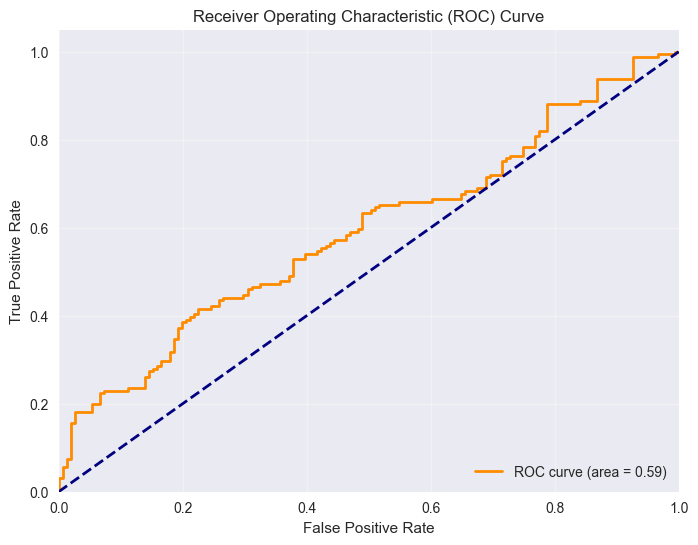


Interpretasi ROC-AUC Curve:
- **ROC (Receiver Operating Characteristic) Curve:** Adalah plot yang menunjukkan kinerja model klasifikasi pada semua ambang batas klasifikasi. Plot ini membandingkan True Positive Rate (Recall) dengan False Positive Rate.
- **AUC (Area Under the Curve):** Adalah area di bawah kurva ROC. Nilai AUC berkisar antara 0.5 (kinerja acak) hingga 1.0 (kinerja sempurna).
- **AUC Score (0.59):** Model kita memiliki AUC sebesar 0.59. Semakin tinggi nilai AUC (mendekati 1.0), semakin baik model dalam membedakan antara kelas positif dan negatif.
  - Kurva yang mendekati sudut kiri atas grafik menunjukkan kinerja model yang lebih baik.


In [17]:
# Cell 12: Goodness of Fit - ROC-AUC Curve
# Memastikan data pengujian dan model tersedia
if 'y_test' in globals() and not y_test.empty and \
   'X_test' in globals() and not X_test.empty and \
   'log_reg_model' in globals():
    print("\n--- Goodness of Fit: ROC-AUC Curve ---")

    y_pred_proba_log_reg = log_reg_model.predict_proba(X_test)[:, 1]

    # Calculate ROC curve
    fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba_log_reg)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend(loc="lower right")
    plt.grid(True, alpha=0.3)
    plt.show()

    print("\nInterpretasi ROC-AUC Curve:")
    print("- **ROC (Receiver Operating Characteristic) Curve:** Adalah plot yang menunjukkan kinerja model klasifikasi pada semua ambang batas klasifikasi. Plot ini membandingkan True Positive Rate (Recall) dengan False Positive Rate.")
    print("- **AUC (Area Under the Curve):** Adalah area di bawah kurva ROC. Nilai AUC berkisar antara 0.5 (kinerja acak) hingga 1.0 (kinerja sempurna).")
    print(f"- **AUC Score ({roc_auc:.2f}):** Model kita memiliki AUC sebesar {roc_auc:.2f}. Semakin tinggi nilai AUC (mendekati 1.0), semakin baik model dalam membedakan antara kelas positif dan negatif.")
    print("  - Kurva yang mendekati sudut kiri atas grafik menunjukkan kinerja model yang lebih baik.")
else:
    print("Data pengujian atau model belum tersedia. Tidak dapat membuat ROC-AUC Curve. Pastikan Cell 10 berhasil dijalankan.")

In [18]:
# Cell 13: Prediksi Kategori Popularitas dengan Input User
# Memastikan variabel global yang diperlukan untuk fungsi prediksi tersedia
if 'X_train' in globals() and not X_train.empty and \
   'log_reg_model' in globals() and \
   'top_genres' in globals():
    print("\n--- Fungsi Prediksi Kategori Popularitas dengan Input User ---")

    def predict_popularity_from_user_input(
        highest_charting_position: int,
        number_of_times_charted: int,
        artist_followers: float,
        release_year: int,
        release_month: int,
        user_genres: list[str] # List genre yang dimasukkan user (misal: ['pop', 'dance pop'])
    ):
        """
        Memprediksi kategori popularitas lagu (High/Low) berdasarkan input pengguna.

        Args:
            highest_charting_position (int): Posisi tertinggi lagu di chart (misal: 1, 5, 20).
            number_of_times_charted (int): Berapa kali lagu masuk chart (misal: 8, 3, 1).
            artist_followers (float): Jumlah followers artis (misal: 5000000.0).
            release_year (int): Tahun rilis lagu (misal: 2022, 2024).
            release_month (int): Bulan rilis lagu (misal: 1-12).
            user_genres (list[str]): List genre yang dimasukkan user (misal: ['pop', 'dance pop']).
                                      Hanya genre yang termasuk dalam top_genres saat training yang akan dipertimbangkan.

        Returns:
            tuple: Prediksi kategori popularitas ('High Popularity' atau 'Low Popularity') dan probabilitas untuk 'High'.
        """
        global features_to_use, X_train, log_reg_model, top_genres # Menggunakan variabel global

        input_data = {}
        for feature in features_to_use:
            if feature.startswith('genre_'):
                input_data[feature] = 0 # Inisialisasi semua fitur genre ke 0
            else:
                # Gunakan median dari data training sebagai nilai default untuk fitur numerik lainnya
                # Ini penting jika fitur numerik lain tidak disediakan secara eksplisit oleh user
                input_data[feature] = X_train[feature].median()

        # Isi nilai fitur dari input user yang spesifik
        input_data['Highest Charting Position'] = highest_charting_position
        input_data['Number of Times Charted'] = number_of_times_charted
        input_data['Artist Followers'] = artist_followers
        input_data['release_year'] = release_year
        input_data['release_month'] = release_month

        # Hitung fitur 'song_age_years' berdasarkan input 'release_year'
        current_year = pd.Timestamp.now().year
        input_data['song_age_years'] = current_year - release_year

        # Set fitur genre biner berdasarkan input user_genres
        for genre in user_genres:
            if genre in top_genres: # Hanya genre yang ada di top_genres saat training yang relevan
                feature_name = f'genre_{genre}'
                if feature_name in input_data: # Pastikan fitur genre ini ada di X_train.columns
                    input_data[feature_name] = 1

        # Buat DataFrame dari dictionary input user.
        # SANGAT PENTING: Pastikan urutan kolom sama dengan X_train.columns.
        # Ini menjamin bahwa fitur-fitur input dipetakan ke bobot model yang benar.
        input_df = pd.DataFrame([input_data], columns=X_train.columns)

        # Lakukan prediksi
        predicted_popularity_category = log_reg_model.predict(input_df)[0]
        predicted_popularity_proba = log_reg_model.predict_proba(input_df)[0, 1]

        category_label = "High Popularity" if predicted_popularity_category == 1 else "Low Popularity"

        return category_label, predicted_popularity_proba

    # --- Contoh Penggunaan Fungsi Prediksi ---
    print("\n--- Contoh Prediksi Kategori Popularitas dengan Input User ---")

    # Contoh input dari pengguna. Anda bisa mengubah nilai-nilai ini.
    user_highest_charting_position = 5
    user_number_of_times_charted = 10
    user_artist_followers = 10000000.0
    user_release_year = 2022
    user_release_month = 6
    user_genres_input = ['pop', 'hip hop']

    predicted_category, predicted_proba = predict_popularity_from_user_input(
        highest_charting_position=user_highest_charting_position,
        number_of_times_charted=user_number_of_times_charted,
        artist_followers=user_artist_followers,
        release_year=user_release_year,
        release_month=user_release_month,
        user_genres=user_genres_input
    )

    print(f"\nInput User yang Diberikan:")
    print(f"  Posisi Chart Tertinggi: {user_highest_charting_position}")
    print(f"  Jumlah Kali Charted: {user_number_of_times_charted}")
    print(f"  Jumlah Followers Artis: {user_artist_followers:,.0f}")
    print(f"  Tahun Rilis: {user_release_year}")
    print(f"  Bulan Rilis: {user_release_month}")
    print(f"  Genre: {user_genres_input}")

    print(f"\n--- Hasil Prediksi ---")
    print(f"Prediksi Kategori Popularitas: {predicted_category}")
    print(f"Probabilitas untuk 'High Popularity': {predicted_proba:.2f}")

    print("\n--- Catatan Penting untuk Prediksi ---\n")
    print("1. **Urutan Eksekusi:** Pastikan semua cell kode ini telah dijalankan dari awal hingga akhir tanpa melewatkan satupun. Ini krusial agar model dilatih dan variabel global yang diperlukan tersedia di lingkungan eksekusi.")
    print("2. **Kelengkapan Fitur:** Fungsi `predict_popularity_from_user_input` secara otomatis mengisi fitur numerik yang tidak diinput langsung oleh user (selain genre) dengan nilai median dari data training. Sesuaikan asumsi ini jika kebutuhan aplikasi Anda berbeda.")
    print("3. **Penanganan Genre:** Hanya genre yang termasuk dalam `top_genres` (yang diidentifikasi saat training) yang akan dipertimbangkan oleh model. Genre lain yang diinput user akan diabaikan karena model tidak 'mengenali' fitur biner untuk genre tersebut.")
    print("4. **Interpretasi Probabilitas:** Probabilitas menunjukkan keyakinan model terhadap prediksi. Semakin tinggi probabilitas (mendekati 1.0), semakin yakin model bahwa lagu tersebut termasuk dalam kategori 'High Popularity'.")
else:
    print("Variabel yang diperlukan untuk fungsi prediksi user input belum tersedia. Pastikan semua cell sebelumnya telah dijalankan dengan benar.")


--- Fungsi Prediksi Kategori Popularitas dengan Input User ---

--- Contoh Prediksi Kategori Popularitas dengan Input User ---

Input User yang Diberikan:
  Posisi Chart Tertinggi: 5
  Jumlah Kali Charted: 10
  Jumlah Followers Artis: 10,000,000
  Tahun Rilis: 2022
  Bulan Rilis: 6
  Genre: ['pop', 'hip hop']

--- Hasil Prediksi ---
Prediksi Kategori Popularitas: High Popularity
Probabilitas untuk 'High Popularity': 0.53

--- Catatan Penting untuk Prediksi ---

1. **Urutan Eksekusi:** Pastikan semua cell kode ini telah dijalankan dari awal hingga akhir tanpa melewatkan satupun. Ini krusial agar model dilatih dan variabel global yang diperlukan tersedia di lingkungan eksekusi.
2. **Kelengkapan Fitur:** Fungsi `predict_popularity_from_user_input` secara otomatis mengisi fitur numerik yang tidak diinput langsung oleh user (selain genre) dengan nilai median dari data training. Sesuaikan asumsi ini jika kebutuhan aplikasi Anda berbeda.
3. **Penanganan Genre:** Hanya genre yang termasuk dal